# UMKM Prediction

- Tim : Pertama-Kali-Ikut-Lomba
- Asal Kampus: Institut Teknologi Sepuluh Nopember
### Deskripsi Variabel Dataset

| No | Variabel | Deskripsi | Tipe Data / Kode |
|----|-----------|------------|------------------|
| 1 | `Age` | Usia pemilik usaha dalam tahun. | Numerik |
| 2 | `Education` | Tingkat pendidikan pemilik usaha. | Ordinal (1 = SD, 2 = SMP, 3 = SMA, 4 = Sarjana, dst.) |
| 3 | `Initial_Capital` | Kecukupan modal awal usaha. | Biner (1 = Memadai, 0 = Tidak Memadai) |
| 4 | `Financial_Record_Keeping` | Kualitas pencatatan keuangan usaha. | Biner (1 = Baik, 0 = Buruk) |
| 5 | `Internet_Usage` | Penggunaan internet dalam menjalankan usaha. | Biner (1 = Ya, 0 = Tidak) |
| 6 | `Business_Plan` | Ketersediaan perencanaan bisnis. | Biner (1 = Ada, 0 = Tidak Ada) |
| 7 | `Marketing_Effort` | Tingkat usaha pemasaran yang dilakukan pemilik usaha. | Skala Likert (1–7) |
| 8 | `Partnership` | Kepemilikan atau keterlibatan dalam kemitraan bisnis. | Biner (1 = Ya, 0 = Tidak) |
| 9 | `Parent_Business_Experience` | Pengalaman bisnis yang dimiliki orang tua. | Biner (1 = Pernah, 0 = Tidak Pernah) |
| 10 | `Industry_Experience` | Lama pengalaman pemilik dalam industri terkait. | Numerik (tahun) |
| 11 | `Owner_Gender` | Jenis kelamin pemilik usaha. | Biner (0 = Perempuan, 1 = Laki-laki) |
| 12 | `Professional_Advice` | Frekuensi konsultasi dengan profesional atau konsultan bisnis. | Skala Likert (1–7) |
| 13 | `Success` | Status keberhasilan usaha yang menjadi target prediksi. | Biner (1 = Berhasil, 0 = Tidak Berhasil) |

### Variabel Target

Variabel target pada dataset ini adalah **`status_keberhasilan`**, yang menunjukkan apakah suatu usaha berhasil atau tidak berhasil berdasarkan karakteristik pemilik dan praktik pengelolaan usaha.

- **1 (Berhasil)** : Usaha berhasil.
- **0 (Tidak Berhasil)** : Usaha tidak berhasil.

In [1]:
# ===== Data & Numerik =====
import numpy as np
import pandas as pd

# ===== Visualisasi =====
import matplotlib.pyplot as plt
import seaborn as sns

# ===== Preprocessing =====
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ===== Model =====
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb

# ===== Metrics =====
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

In [2]:
data = pd.read_csv('umkm_success.csv')
data

,Age,Education,Initial_Capital,Financial_Record_Keeping,Internet_Usage,Business_Plan,Marketing_Effort,Partnership,Parent_Business_Experience,Industry_Experience,Owner_Gender,Professional_Advice,Success
0,60,3,0,0,0,0,5,1,1,5,1,3,0
1,51,4,1,1,0,0,7,1,1,4,1,7,0
2,21,1,0,1,1,0,7,0,0,19,1,2,0
3,20,1,0,1,1,1,5,1,0,1,1,2,0
4,35,1,1,1,0,1,3,0,1,3,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,36,3,1,1,0,1,5,0,0,2,1,4,0
246,44,2,1,0,0,1,3,1,1,6,0,1,0
247,38,2,0,0,0,1,2,1,1,10,0,5,0
248,26,5,0,1,0,1,5,1,1,12,0,2,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Age                         250 non-null    int64
 1   Education                   250 non-null    int64
 2   Initial_Capital             250 non-null    int64
 3   Financial_Record_Keeping    250 non-null    int64
 4   Internet_Usage              250 non-null    int64
 5   Business_Plan               250 non-null    int64
 6   Marketing_Effort            250 non-null    int64
 7   Partnership                 250 non-null    int64
 8   Parent_Business_Experience  250 non-null    int64
 9   Industry_Experience         250 non-null    int64
 10  Owner_Gender                250 non-null    int64
 11  Professional_Advice         250 non-null    int64
 12  Success                     250 non-null    int64
dtypes: int64(13)
memory usage: 25.5 KB


In [4]:
## Verifikasi data
print("Jumlah data yang hilang (null) di setiap kolom:")
print(data.isnull().sum())
print("Jumlah data duplikat:")
print(data.duplicated().sum())
print("Jumlah data yang hilang (Nan) di setiap kolom:")
print(data.isna().sum())

Jumlah data yang hilang (null) di setiap kolom:
Age                           0
Education                     0
Initial_Capital               0
Financial_Record_Keeping      0
Internet_Usage                0
Business_Plan                 0
Marketing_Effort              0
Partnership                   0
Parent_Business_Experience    0
Industry_Experience           0
Owner_Gender                  0
Professional_Advice           0
Success                       0
dtype: int64
Jumlah data duplikat:
0
Jumlah data yang hilang (Nan) di setiap kolom:
Age                           0
Education                     0
Initial_Capital               0
Financial_Record_Keeping      0
Internet_Usage                0
Business_Plan                 0
Marketing_Effort              0
Partnership                   0
Parent_Business_Experience    0
Industry_Experience           0
Owner_Gender                  0
Professional_Advice           0
Success                       0
dtype: int64


In [5]:
data.describe()

,Age,Education,Initial_Capital,Financial_Record_Keeping,Internet_Usage,Business_Plan,Marketing_Effort,Partnership,Parent_Business_Experience,Industry_Experience,Owner_Gender,Professional_Advice,Success
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,39.760000,2.876000,0.516000,0.488000,0.440000,0.524000,3.996000,0.460000,0.440000,9.760000,0.564000,4.140000,0.248000
std,12.805559,1.407319,0.500746,0.500859,0.497383,0.500426,1.992955,0.499397,0.497383,6.164935,0.496882,2.078867,0.432718
min,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,29.000000,2.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,5.000000,0.000000,2.000000,0.000000
50%,40.000000,3.000000,1.000000,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,10.000000,1.000000,4.000000,0.000000
75%,51.000000,4.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,15.000000,1.000000,6.000000,0.000000
max,60.000000,5.000000,1.000000,1.000000,1.000000,1.000000,7.000000,1.000000,1.000000,20.000000,1.000000,7.000000,1.000000


In [6]:
target_column = "Success"
semua_fitur = [col for col in data.columns if col != target_column]

df_stat = data[semua_fitur].describe().T

df_stat_filtered = df_stat[["mean", "std", "min", "max"]]

df_stat_filtered = df_stat_filtered.reset_index()
df_stat_filtered.columns = ["Fitur", "Mean", "Std_Deviation", "Min", "Max"]

df_stat_filtered[["Mean", "Std_Deviation", "Min", "Max"]] = df_stat_filtered[
    ["Mean", "Std_Deviation", "Min", "Max"]
].round(2)

nama_file_rapi = "statistik.csv"
df_stat_filtered.to_csv(nama_file_rapi, index=False)

print(f"File statistik 2 desimal berhasil disimpan: {nama_file_rapi}")
print("\nIsi Tabel Rapi (2 Desimal):")
print(df_stat_filtered)

File statistik 2 desimal berhasil disimpan: statistik.csv

Isi Tabel Rapi (2 Desimal):
                         Fitur   Mean  Std_Deviation   Min   Max
0                          Age  39.76          12.81  18.0  60.0
1                    Education   2.88           1.41   1.0   5.0
2              Initial_Capital   0.52           0.50   0.0   1.0
3     Financial_Record_Keeping   0.49           0.50   0.0   1.0
4               Internet_Usage   0.44           0.50   0.0   1.0
5                Business_Plan   0.52           0.50   0.0   1.0
6             Marketing_Effort   4.00           1.99   1.0   7.0
7                  Partnership   0.46           0.50   0.0   1.0
8   Parent_Business_Experience   0.44           0.50   0.0   1.0
9          Industry_Experience   9.76           6.16   0.0  20.0
10                Owner_Gender   0.56           0.50   0.0   1.0
11         Professional_Advice   4.14           2.08   1.0   7.0


## **Eksplorasi Data**

C:\Users\Liza\AppData\Local\Temp\ipykernel_8644\3014960359.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_plot = sns.countplot(data=data, x=col, ax=axes[i], palette='viridis')
C:\Users\Liza\AppData\Local\Temp\ipykernel_8644\3014960359.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_plot = sns.countplot(data=data, x=col, ax=axes[i], palette='viridis')
C:\Users\Liza\AppData\Local\Temp\ipykernel_8644\3014960359.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_plot = sns.countplot(data=data, x=col, ax=axes[i], palette='viridis')
C:\Users\Liza\AppData\Local\

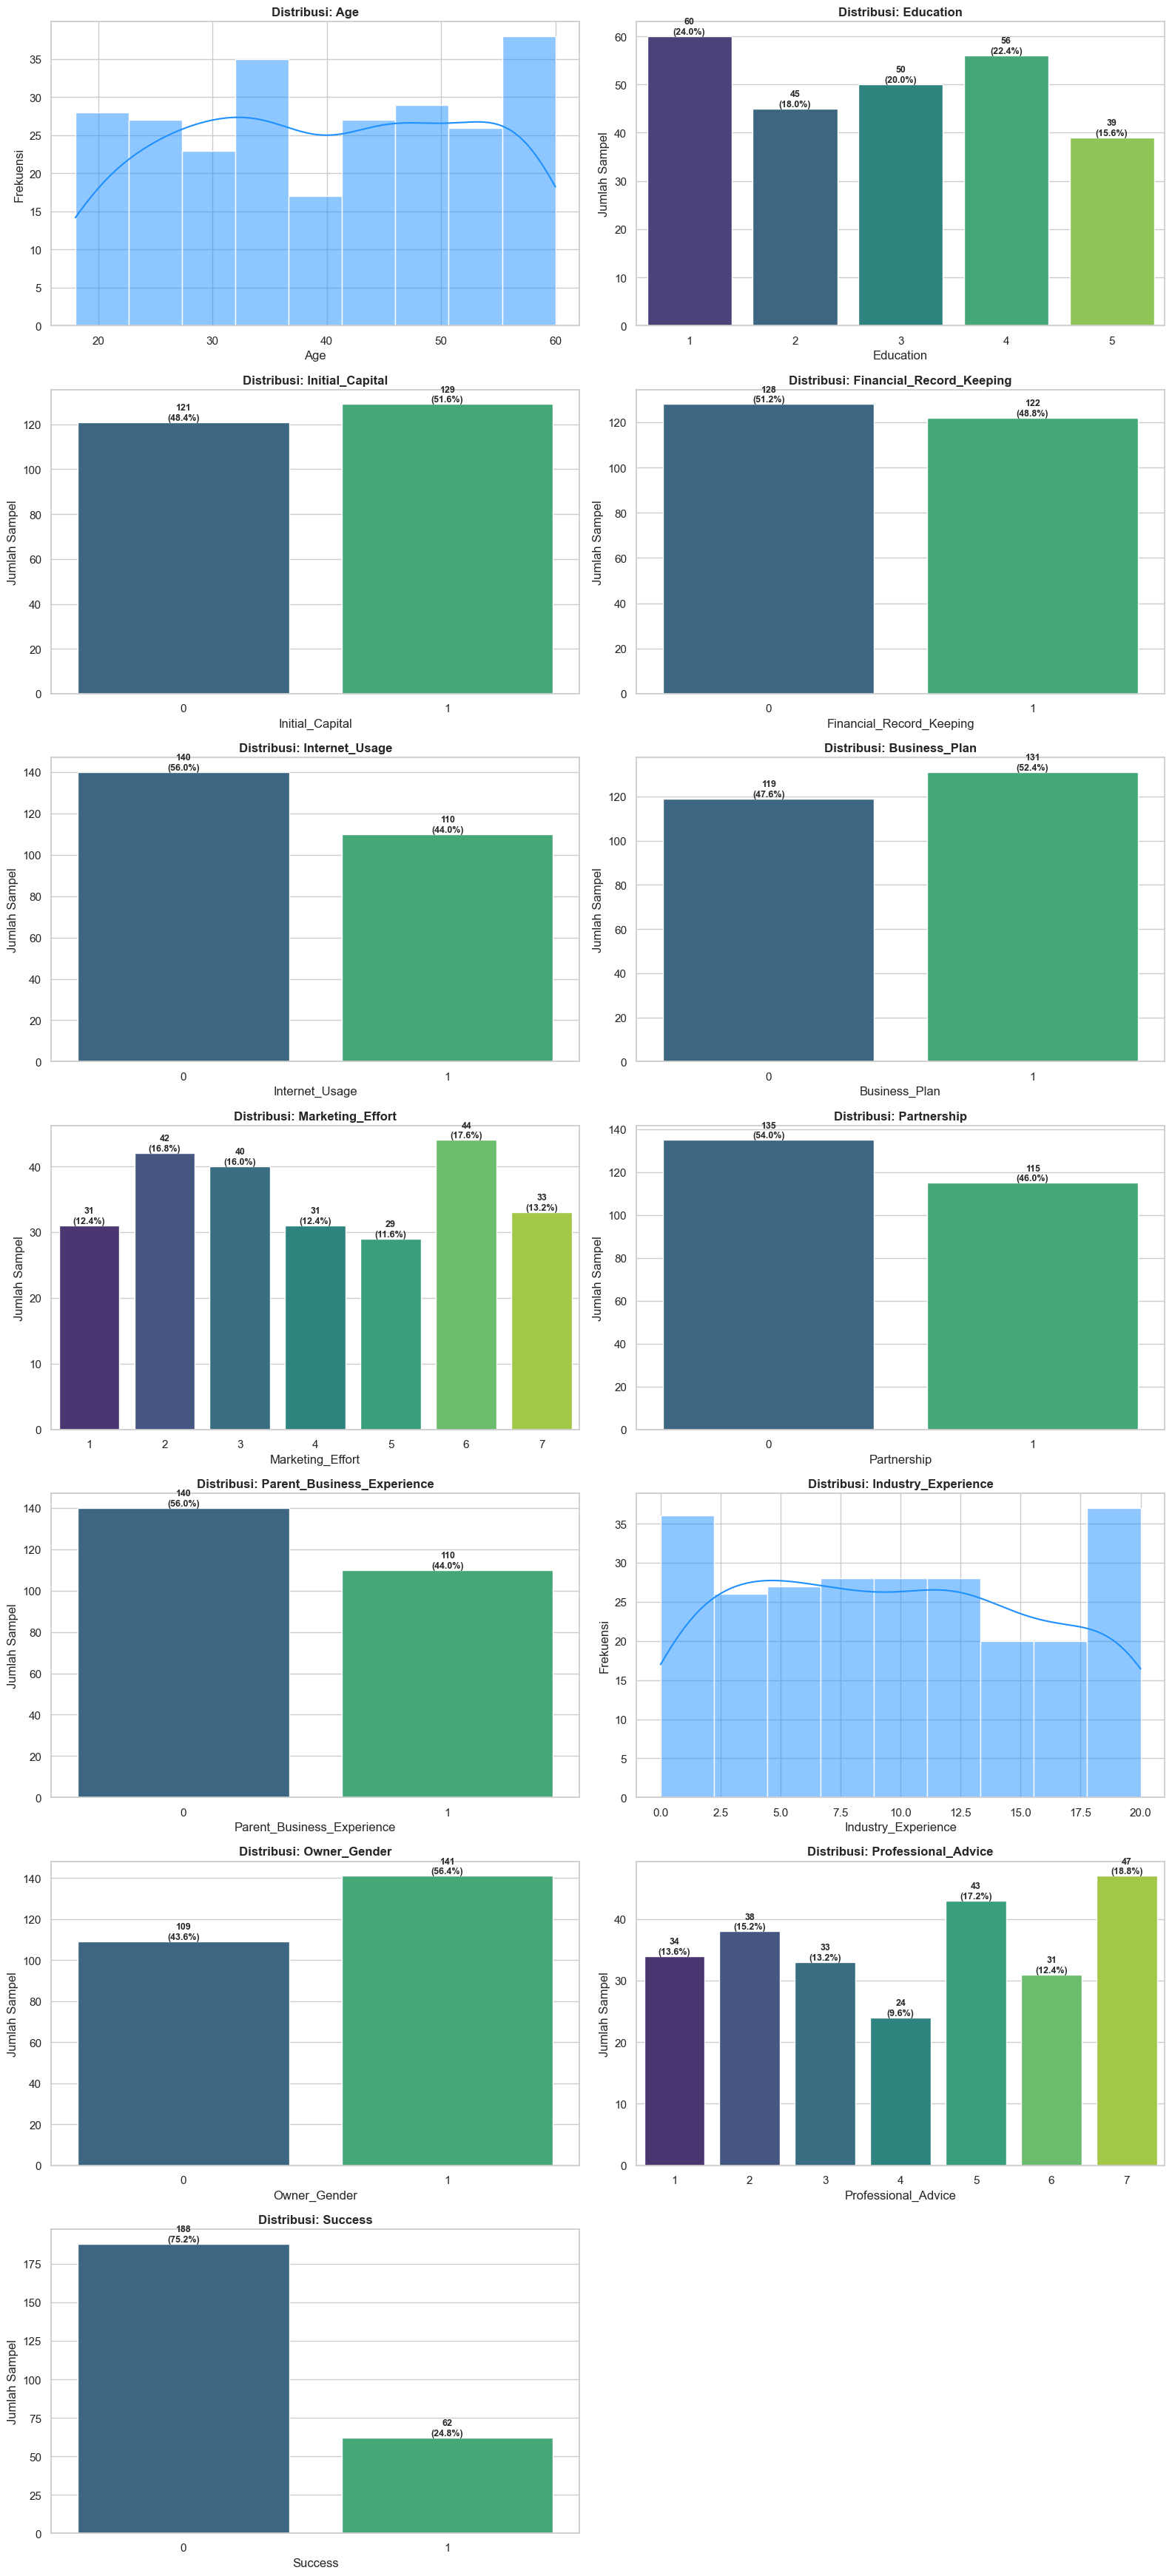

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_theme(style="whitegrid")

semua_kolom = [
    'Age', 'Education', 'Initial_Capital', 'Financial_Record_Keeping',
    'Internet_Usage', 'Business_Plan', 'Marketing_Effort', 'Partnership',
    'Parent_Business_Experience', 'Industry_Experience', 'Owner_Gender',
    'Professional_Advice', 'Success'
]

kolom_numerik = ['Age', 'Industry_Experience']

jumlah_kolom_plot = 2
jumlah_baris_plot = math.ceil(len(semua_kolom) / jumlah_kolom_plot)

fig, axes = plt.subplots(jumlah_baris_plot, jumlah_kolom_plot, figsize=(16, jumlah_baris_plot * 5))
axes = axes.flatten()  

for i, col in enumerate(semua_kolom):
    if col in kolom_numerik:
        sns.histplot(data=data, x=col, kde=True, ax=axes[i], color='dodgerblue')
        axes[i].set_title(f'Distribusi: {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frekuensi')
        
    else:
        ax_plot = sns.countplot(data=data, x=col, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribusi: {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(f'{col}')
        axes[i].set_ylabel('Jumlah Sampel')
        
        total = len(data[col])
        for p in ax_plot.patches:
            height = p.get_height()
            if height > 0:  
                percentage = f'{100 * height / total:.1f}%'
                x = p.get_x() + p.get_width() / 2
                y = height
                ax_plot.annotate(f'{int(height)}\n({percentage})', (x, y), 
                                 ha='center', va='bottom', fontsize=9, fontweight='bold')

if len(semua_kolom) < len(axes):
    for j in range(len(semua_kolom), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

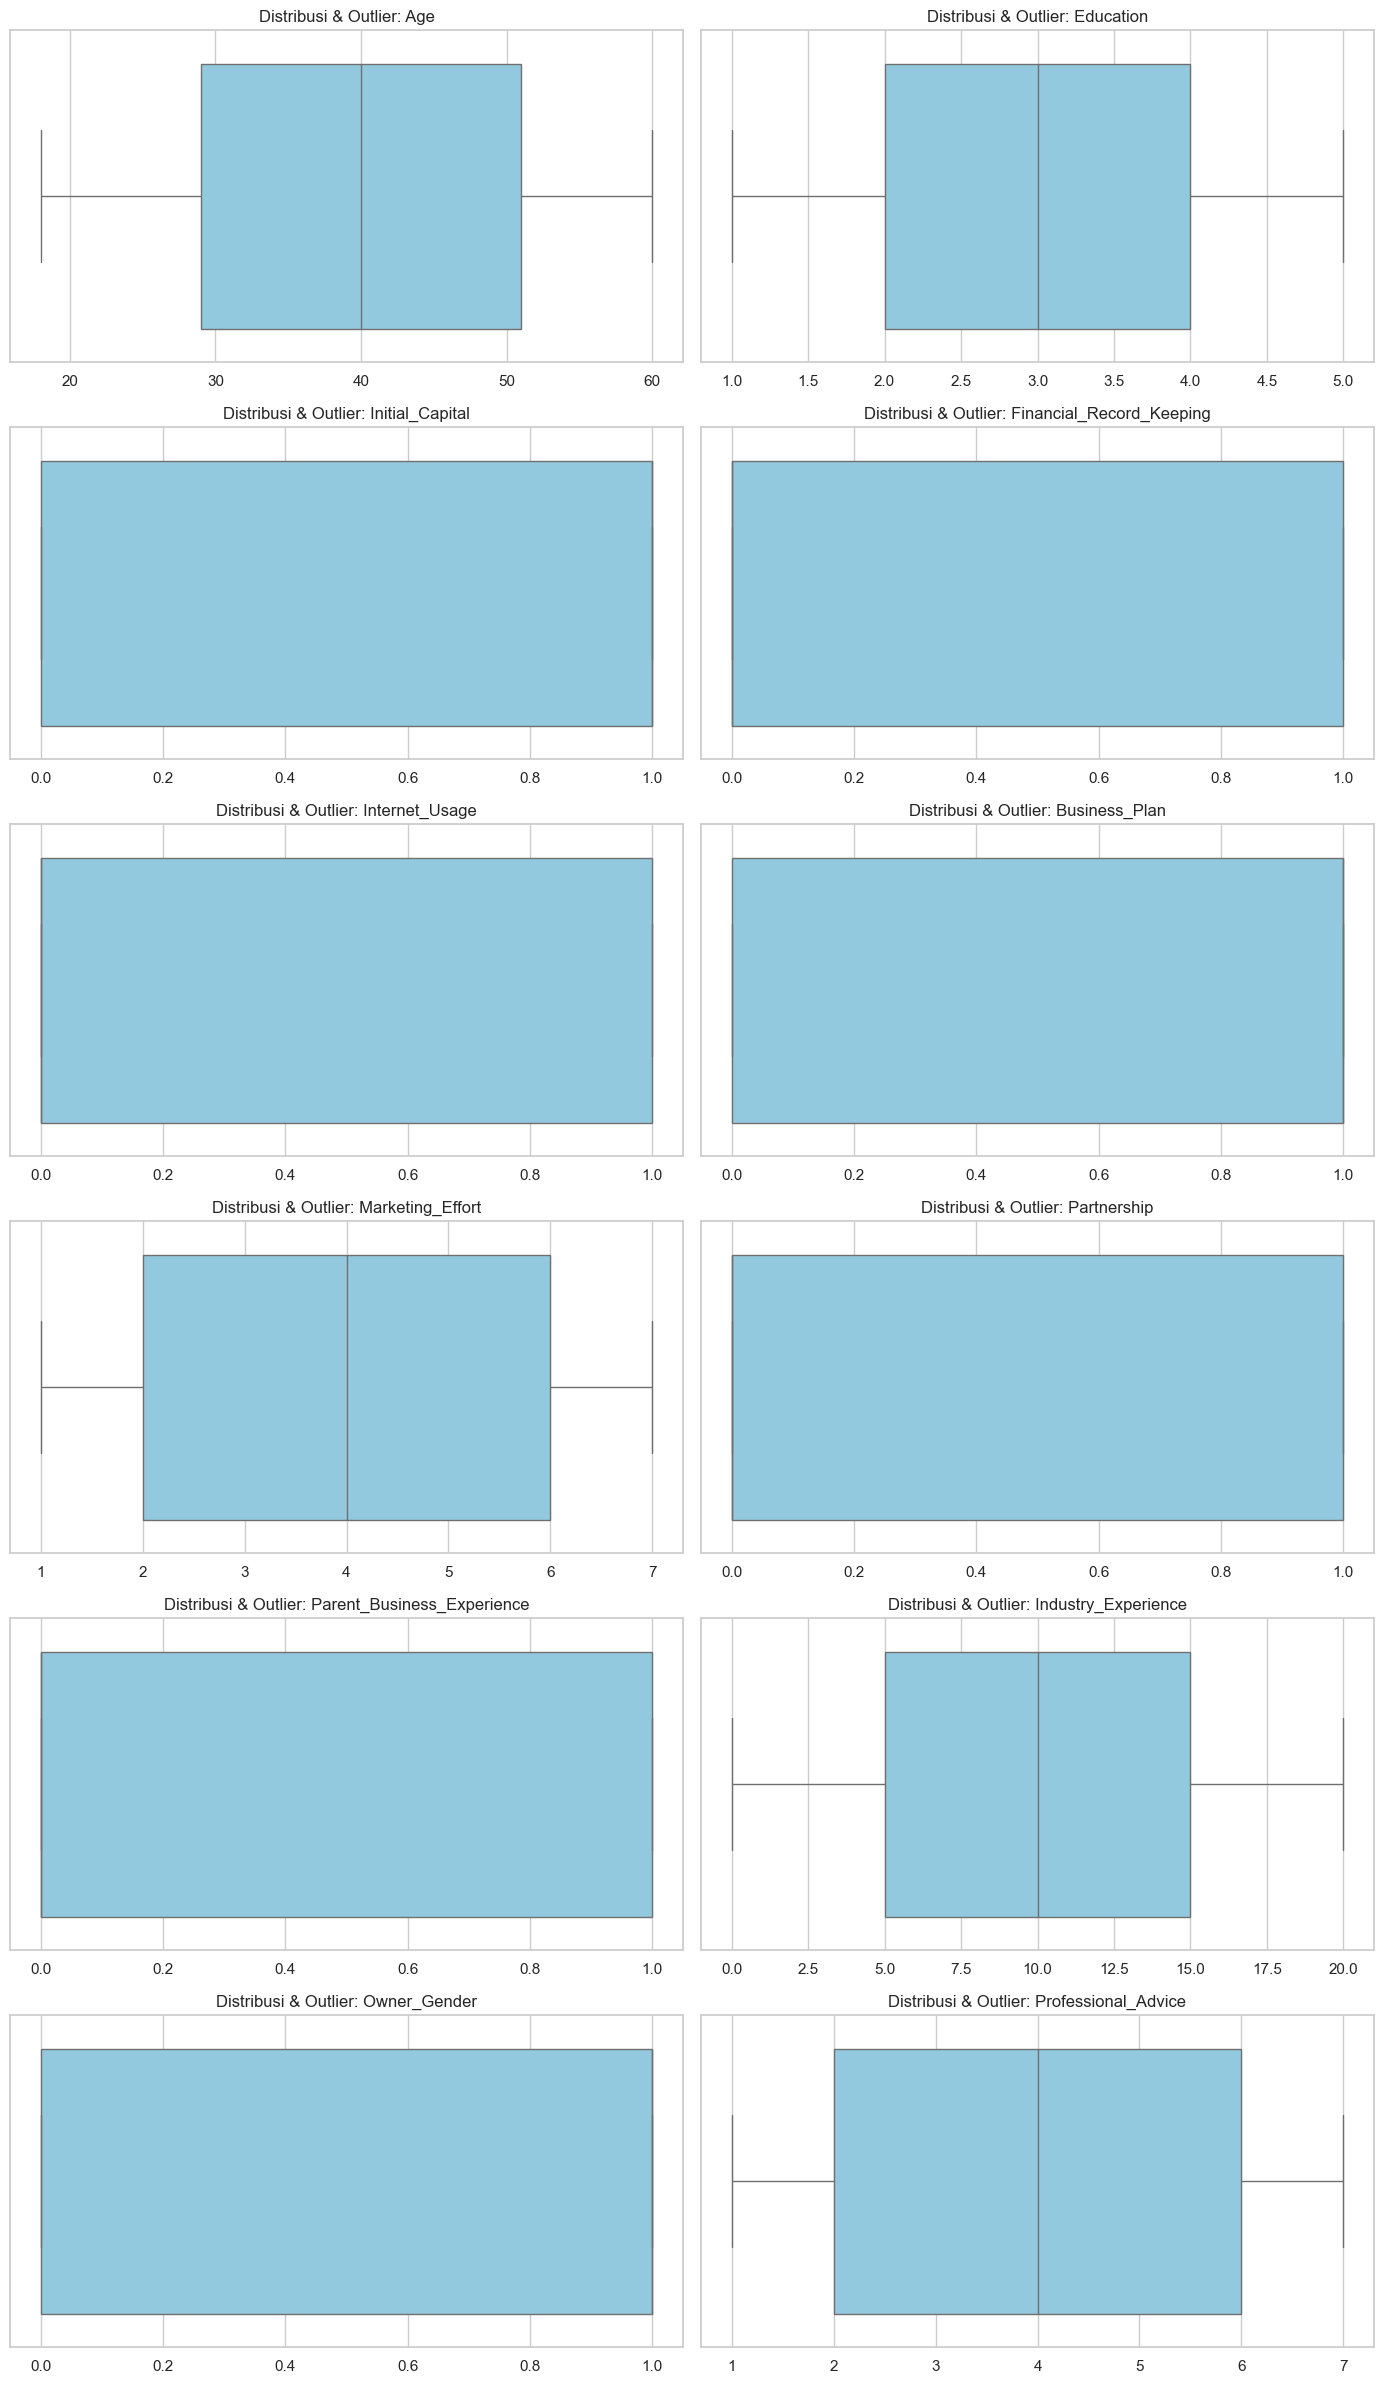

In [8]:
## Boxplot untuk mendeteksi outlier
ignored_columns = ["Success"]
features = [col for col in data.columns if col not in ignored_columns]

ncols = 2
nrows = math.ceil(len(features) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows))
axes = axes.flatten() 
for i, col in enumerate(features):
    sns.boxplot(x=data[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribusi & Outlier: {col}", fontsize=12)
    axes[i].set_xlabel("")  
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

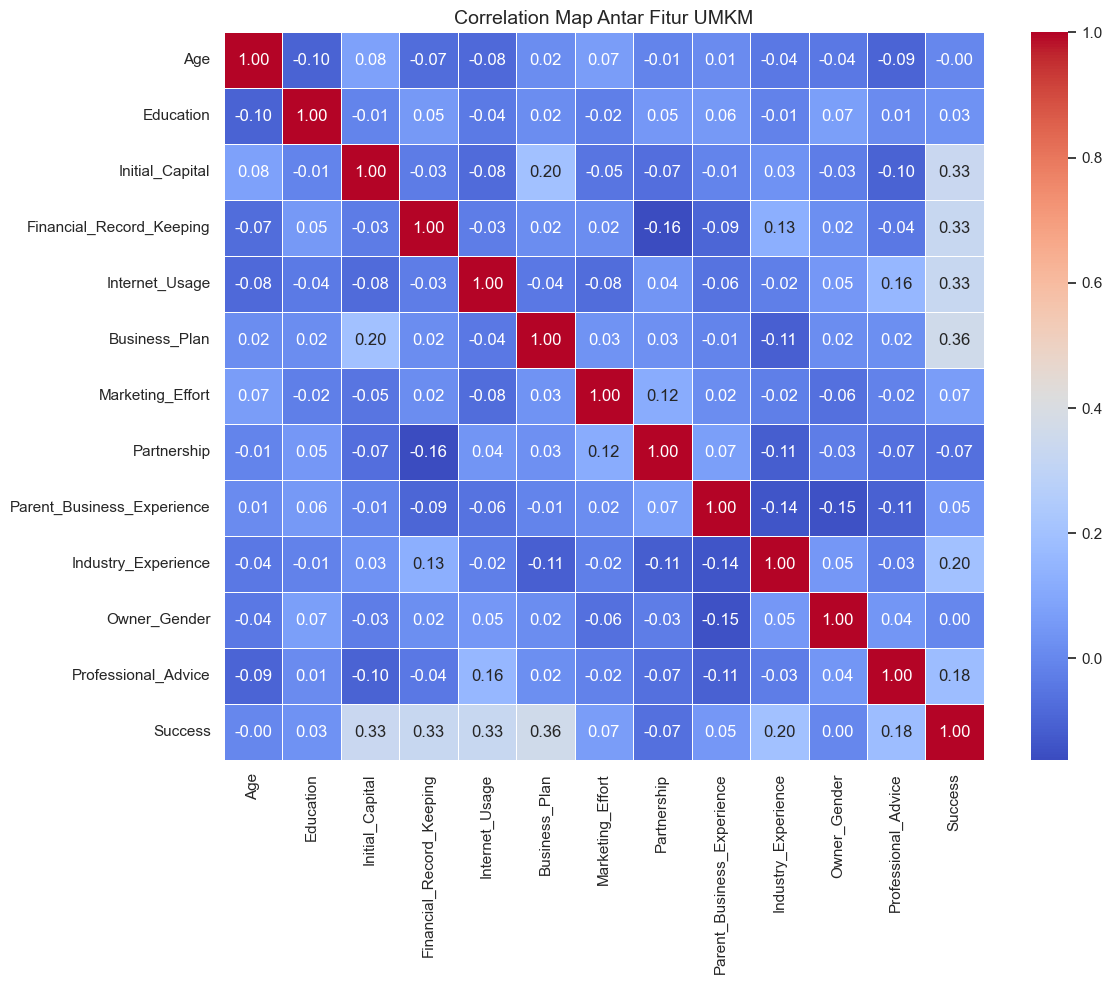

In [9]:
features_only = data.drop(columns=["status_keberhasilan", "success"], errors="ignore")
corr_matrix = features_only.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,  
    cmap="coolwarm",  
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Correlation Map Antar Fitur UMKM", fontsize=14)
plt.tight_layout()

## **Training**

# Skenario 1: Perbandingan Model dengan Semua fitur digunakan

### Dengan Normalisasi MinMax

In [10]:

# ==========================================
# 1. PEMISAHAN FITUR & TARGET (SPLIT DATA)
# ==========================================
target_column = "Success"

X = data.drop(columns=[target_column])
y = data[target_column]

# Split data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- CETAK DISTRIBUSI LABEL (Target) ---
print("=" * 45)
print("       DISTRIBUSI LABEL TARGET ('Success')      ")
print("=" * 45)


def print_distribusi(label_series, nama_set):
    counts = label_series.value_counts()
    percentages = label_series.value_counts(normalize=True) * 100
    print(f"\n[ {nama_set} - Total: {len(label_series)} sampel ]")
    for kelas in counts.index:
        print(
            f"  Kelas {kelas}: {counts[kelas]} sampel ({percentages[kelas]:.1f}%)"
        )


print_distribusi(y, "TOTAL DATA")
print_distribusi(y_train, "DATA TRAIN")
print_distribusi(y_test, "DATA TEST")
print("-" * 45)
print(f"Jumlah Fitur Latih (X_train): {X_train.shape[0]} sampel")
print(f"Jumlah Fitur Uji (X_test)  : {X_test.shape[0]} sampel\n")


# ==========================================
# 2. NORMALISASI (SCALING)
# ==========================================
numeric_cols = ["Age", "Industry_Experience", "Marketing_Effort", "Professional_Advice"]
numeric_cols = [col for col in numeric_cols if col in X_train.columns]

scaler = MinMaxScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])



       DISTRIBUSI LABEL TARGET ('Success')      

[ TOTAL DATA - Total: 250 sampel ]
  Kelas 0: 188 sampel (75.2%)
  Kelas 1: 62 sampel (24.8%)

[ DATA TRAIN - Total: 200 sampel ]
  Kelas 0: 150 sampel (75.0%)
  Kelas 1: 50 sampel (25.0%)

[ DATA TEST - Total: 50 sampel ]
  Kelas 0: 38 sampel (76.0%)
  Kelas 1: 12 sampel (24.0%)
---------------------------------------------
Jumlah Fitur Latih (X_train): 200 sampel
Jumlah Fitur Uji (X_test)  : 50 sampel



In [11]:
from sklearn.metrics import classification_report

def evaluasi_cepat(nama_strategi, y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    
    acc = report["accuracy"]
    prec_macro = report["macro avg"]["precision"]
    rec_macro = report["macro avg"]["recall"]
    f1_macro = report["macro avg"]["f1-score"]

    print(f"=== STRATEGI: {nama_strategi} ===")
    print(f"Accuracy           : {acc:.4f} ({acc * 100:.1f}%)")
    print(f"Precision (Macro)  : {prec_macro:.4f} ({prec_macro * 100:.1f}%)")
    print(f"Recall (Macro)     : {rec_macro:.4f} ({rec_macro * 100:.1f}%)")
    print(f"F1-Score (Macro)   : {f1_macro:.4f} ({f1_macro * 100:.1f}%)")
    print("\n--- REPORT LENGKAP ---")
    print(classification_report(y_true, y_pred))  
    print("=" * 45 + "\n")

## Logistic Regression

In [12]:
# model baseline Logistic Regression (tanpa tuning)
model_lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
model_lr_baseline.fit(X_train, y_train)

y_pred_lr_baseline = model_lr_baseline.predict(X_test)
evaluasi_cepat("Logistic Regression Tanpa Tuning", y_test, y_pred_lr_baseline)

=== STRATEGI: Logistic Regression Tanpa Tuning ===
Accuracy           : 0.9400 (94.0%)
Precision (Macro)  : 0.9096 (91.0%)
Recall (Macro)     : 0.9320 (93.2%)
F1-Score (Macro)   : 0.9200 (92.0%)

--- REPORT LENGKAP ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        38
           1       0.85      0.92      0.88        12

    accuracy                           0.94        50
   macro avg       0.91      0.93      0.92        50
weighted avg       0.94      0.94      0.94        50




In [13]:
# model optimal Logistic Regression dengan class_weight='balanced'
model_lr = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)

y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

best_thresh_lr = 0.5
best_f1_lr = 0
y_pred_lr_opt = None

for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (y_proba_lr >= thresh).astype(int)
    current_f1 = f1_score(y_test, preds, pos_label=1)
    if current_f1 > best_f1_lr:
        best_f1_lr = current_f1
        best_thresh_lr = thresh
        y_pred_lr_opt = preds

# Menghitung metrik evaluasi
acc_lr = accuracy_score(y_test, y_pred_lr_opt)
prec_macro_lr = precision_score(y_test, y_pred_lr_opt, average="macro")
rec_macro_lr = recall_score(y_test, y_pred_lr_opt, average="macro")
f1_macro_lr = f1_score(y_test, y_pred_lr_opt, average="macro")

# Menampilkan output dengan format yang konsisten
print("=" * 45)
print("     METRIK EVALUASI LOGISTIC REGRESSION (GENERAL)    ")
print("=" * 45)
print(f"Threshold Optimal Logistic Reg  : {best_thresh_lr:.2f}")
print(f"Accuracy                        : {acc_lr:.4f} ({acc_lr*100:.1f}%)")
print(f"Precision (Macro Mean)          : {prec_macro_lr:.4f} ({prec_macro_lr*100:.1f}%)")
print(f"Recall (Macro Mean)             : {rec_macro_lr:.4f} ({rec_macro_lr*100:.1f}%)")
print(f"F1-Score (Macro Mean)           : {f1_macro_lr:.4f} ({f1_macro_lr*100:.1f}%)")
print("-" * 45)

print("\n--- REPORT LENGKAP LOGISTIC REGRESSION OPTIMAL ---")
print(classification_report(y_test, y_pred_lr_opt))
print("=" * 45)

     METRIK EVALUASI LOGISTIC REGRESSION (GENERAL)    
Threshold Optimal Logistic Reg  : 0.64
Accuracy                        : 0.9600 (96.0%)
Precision (Macro Mean)          : 0.9286 (92.9%)
Recall (Macro Mean)             : 0.9737 (97.4%)
F1-Score (Macro Mean)           : 0.9480 (94.8%)
---------------------------------------------

--- REPORT LENGKAP LOGISTIC REGRESSION OPTIMAL ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        38
           1       0.86      1.00      0.92        12

    accuracy                           0.96        50
   macro avg       0.93      0.97      0.95        50
weighted avg       0.97      0.96      0.96        50



## Tree Tanpa Normalisasi

In [20]:

# ==========================================
# 1. PEMISAHAN FITUR & TARGET (SPLIT DATA)
# ==========================================
target_column = "Success"

X = data.drop(columns=[target_column])
y = data[target_column]

# Split data: 80% Train, 20% Test dengan Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- CETAK DISTRIBUSI LABEL (Target) ---
print("=" * 45)
print("       DISTRIBUSI LABEL TARGET ('Success')      ")
print("=" * 45)


def print_distribusi(label_series, nama_set):
    counts = label_series.value_counts()
    percentages = label_series.value_counts(normalize=True) * 100
    print(f"\n[ {nama_set} - Total: {len(label_series)} sampel ]")
    for kelas in counts.index:
        print(
            f"  Kelas {kelas}: {counts[kelas]} sampel ({percentages[kelas]:.1f}%)"
        )


print_distribusi(y, "TOTAL DATA")
print_distribusi(y_train, "DATA TRAIN")
print_distribusi(y_test, "DATA TEST")
print("-" * 45)
print(f"Jumlah Fitur Latih (X_train): {X_train.shape[0]} sampel")
print(f"Jumlah Fitur Uji (X_test)  : {X_test.shape[0]} sampel\n")
print("=" * 45)
print(" KONDISI DATA: Tanpa Normalisasi ")
print("=============================================")

       DISTRIBUSI LABEL TARGET ('Success')      

[ TOTAL DATA - Total: 250 sampel ]
  Kelas 0: 188 sampel (75.2%)
  Kelas 1: 62 sampel (24.8%)

[ DATA TRAIN - Total: 200 sampel ]
  Kelas 0: 150 sampel (75.0%)
  Kelas 1: 50 sampel (25.0%)

[ DATA TEST - Total: 50 sampel ]
  Kelas 0: 38 sampel (76.0%)
  Kelas 1: 12 sampel (24.0%)
---------------------------------------------
Jumlah Fitur Latih (X_train): 200 sampel
Jumlah Fitur Uji (X_test)  : 50 sampel

 KONDISI DATA: Tanpa Normalisasi 


## Random Forest

In [21]:
model_rf_baseline = RandomForestClassifier(random_state=42)
model_rf_baseline.fit(X_train, y_train)
y_pred_rf_baseline = model_rf_baseline.predict(X_test)

evaluasi_cepat("Random Forest Tanpa Tuning", y_test, y_pred_rf_baseline)

=== STRATEGI: Random Forest Tanpa Tuning ===
Accuracy           : 0.8000 (80.0%)
Precision (Macro)  : 0.7424 (74.2%)
Recall (Macro)     : 0.6404 (64.0%)
F1-Score (Macro)   : 0.6612 (66.1%)

--- REPORT LENGKAP ---
              precision    recall  f1-score   support

           0       0.82      0.95      0.88        38
           1       0.67      0.33      0.44        12

    accuracy                           0.80        50
   macro avg       0.74      0.64      0.66        50
weighted avg       0.78      0.80      0.77        50




In [22]:
model_rf = RandomForestClassifier(
    class_weight="balanced",
    max_depth=4,         
    n_estimators=200,
    random_state=42
)
model_rf.fit(X_train, y_train)

y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

best_thresh_rf = 0.5
best_f1_rf = 0
y_pred_rf_opt = None

for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (y_proba_rf >= thresh).astype(int)
    current_f1 = f1_score(y_test, preds, pos_label=1)
    if current_f1 > best_f1_rf:
        best_f1_rf = current_f1
        best_thresh_rf = thresh
        y_pred_rf_opt = preds

acc_rf = accuracy_score(y_test, y_pred_rf_opt)
prec_macro_rf = precision_score(y_test, y_pred_rf_opt, average="macro")
rec_macro_rf = recall_score(y_test, y_pred_rf_opt, average="macro")
f1_macro_rf = f1_score(y_test, y_pred_rf_opt, average="macro")

print("=" * 45)
print("     METRIK EVALUASI RANDOM FOREST (GENERAL)      ")
print("=" * 45)
print(f"Threshold Optimal Random Forest : {best_thresh_rf:.2f}")
print(f"Accuracy                       : {acc_rf:.4f} ({acc_rf*100:.1f}%)")
print(f"Precision (Macro Mean)         : {prec_macro_rf:.4f} ({prec_macro_rf*100:.1f}%)")
print(f"Recall (Macro Mean)            : {rec_macro_rf:.4f} ({rec_macro_rf*100:.1f}%)")
print(f"F1-Score (Macro Mean)          : {f1_macro_rf:.4f} ({f1_macro_rf*100:.1f}%)")
print("-" * 45)

print("\n--- REPORT LENGKAP RANDOM FOREST OPTIMAL ---")
print(classification_report(y_test, y_pred_rf_opt))
print("=" * 45)

     METRIK EVALUASI RANDOM FOREST (GENERAL)      
Threshold Optimal Random Forest : 0.52
Accuracy                       : 0.8800 (88.0%)
Precision (Macro Mean)         : 0.8294 (82.9%)
Recall (Macro Mean)            : 0.8640 (86.4%)
F1-Score (Macro Mean)          : 0.8441 (84.4%)
---------------------------------------------

--- REPORT LENGKAP RANDOM FOREST OPTIMAL ---
              precision    recall  f1-score   support

           0       0.94      0.89      0.92        38
           1       0.71      0.83      0.77        12

    accuracy                           0.88        50
   macro avg       0.83      0.86      0.84        50
weighted avg       0.89      0.88      0.88        50



## XGBOOST

In [23]:
# model baseline XGBoost (tanpa tuning)
model_xgb_baseline = xgb.XGBClassifier(random_state=42, eval_metric="logloss")
model_xgb_baseline.fit(X_train, y_train)
y_pred_xgb_baseline = model_xgb_baseline.predict(X_test)

evaluasi_cepat("XGBoost Tanpa Tuning", y_test, y_pred_xgb_baseline)

=== STRATEGI: XGBoost Tanpa Tuning ===
Accuracy           : 0.9200 (92.0%)
Precision (Macro)  : 0.8904 (89.0%)
Recall (Macro)     : 0.8904 (89.0%)
F1-Score (Macro)   : 0.8904 (89.0%)

--- REPORT LENGKAP ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        38
           1       0.83      0.83      0.83        12

    accuracy                           0.92        50
   macro avg       0.89      0.89      0.89        50
weighted avg       0.92      0.92      0.92        50




In [24]:
# model optimal XGBoost
ratio = 188 / 62

model_xgb = xgb.XGBClassifier(
    scale_pos_weight=ratio,
    learning_rate=0.05,
    max_depth=4,
    n_estimators=200,
    random_state=42,
    eval_metric="logloss",
)

model_xgb.fit(X_train, y_train)

y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

best_thresh_xgb = 0.5
best_f1_xgb = 0
y_pred_xgb_opt = None

for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (y_proba_xgb >= thresh).astype(int)
    current_f1 = f1_score(y_test, preds, pos_label=1)
    if current_f1 > best_f1_xgb:
        best_f1_xgb = current_f1
        best_thresh_xgb = thresh
        y_pred_xgb_opt = preds


acc_xgb = accuracy_score(y_test, y_pred_xgb_opt)
prec_macro_xgb = precision_score(y_test, y_pred_xgb_opt, average="macro")
rec_macro_xgb = recall_score(y_test, y_pred_xgb_opt, average="macro")
f1_macro_xgb = f1_score(y_test, y_pred_xgb_opt, average="macro")

print("=" * 45)
print("     METRIK EVALUASI XGBOOST (GENERAL)       ")
print("=" * 45)
print(f"Threshold Optimal XGBoost : {best_thresh_xgb:.2f}")
print(f"Accuracy                  : {acc_xgb:.4f} ({acc_xgb*100:.1f}%)")
print(f"Precision (Macro Mean)    : {prec_macro_xgb:.4f} ({prec_macro_xgb*100:.1f}%)")
print(f"Recall (Macro Mean)       : {rec_macro_xgb:.4f} ({rec_macro_xgb*100:.1f}%)")
print(f"F1-Score (Macro Mean)     : {f1_macro_xgb:.4f} ({f1_macro_xgb*100:.1f}%)")
print("-" * 45)

print("\n--- REPORT LENGKAP XGBOOST OPTIMAL ---")
print(classification_report(y_test, y_pred_xgb_opt))
print("=" * 45)

     METRIK EVALUASI XGBOOST (GENERAL)       
Threshold Optimal XGBoost : 0.63
Accuracy                  : 0.9200 (92.0%)
Precision (Macro Mean)    : 0.9125 (91.3%)
Recall (Macro Mean)       : 0.8618 (86.2%)
F1-Score (Macro Mean)     : 0.8834 (88.3%)
---------------------------------------------

--- REPORT LENGKAP XGBOOST OPTIMAL ---
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        38
           1       0.90      0.75      0.82        12

    accuracy                           0.92        50
   macro avg       0.91      0.86      0.88        50
weighted avg       0.92      0.92      0.92        50



## LightGBM

In [25]:
# model baseline LightGBM (tanpa tuning)
model_lgb_baseline = lgb.LGBMClassifier(random_state=42, verbose=-1)
model_lgb_baseline.fit(X_train, y_train)
y_pred_lgb_baseline = model_lgb_baseline.predict(X_test)

evaluasi_cepat("LightGBM Tanpa Tuning", y_test, y_pred_lgb_baseline)

=== STRATEGI: LightGBM Tanpa Tuning ===
Accuracy           : 0.8800 (88.0%)
Precision (Macro)  : 0.8500 (85.0%)
Recall (Macro)     : 0.8070 (80.7%)
F1-Score (Macro)   : 0.8252 (82.5%)

--- REPORT LENGKAP ---
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        38
           1       0.80      0.67      0.73        12

    accuracy                           0.88        50
   macro avg       0.85      0.81      0.83        50
weighted avg       0.88      0.88      0.88        50




In [26]:
# model optimal
ratio = 188 / 62

model_lgb = lgb.LGBMClassifier(
    scale_pos_weight=ratio,
    learning_rate=0.05,
    max_depth=4,
    n_estimators=200,
    random_state=42,
    verbose=-1,
)
model_lgb.fit(X_train, y_train)

y_proba_lgb = model_lgb.predict_proba(X_test)[:, 1]

best_thresh_lgb = 0.5
best_f1_lgb = 0
y_pred_lgb_opt = None

for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (y_proba_lgb >= thresh).astype(int)
    current_f1 = f1_score(y_test, preds, pos_label=1)
    if current_f1 > best_f1_lgb:
        best_f1_lgb = current_f1
        best_thresh_lgb = thresh
        y_pred_lgb_opt = preds

acc_lgb = accuracy_score(y_test, y_pred_lgb_opt)
prec_macro_lgb = precision_score(y_test, y_pred_lgb_opt, average="macro")
rec_macro_lgb = recall_score(y_test, y_pred_lgb_opt, average="macro")
f1_macro_lgb = f1_score(y_test, y_pred_lgb_opt, average="macro")

print("=" * 45)
print("     METRIK EVALUASI LIGHTGBM (GENERAL)      ")
print("=" * 45)
print(f"Threshold Optimal LightGBM : {best_thresh_lgb:.2f}")
print(f"Accuracy                  : {acc_lgb:.4f} ({acc_lgb*100:.1f}%)")
print(f"Precision (Macro Mean)    : {prec_macro_lgb:.4f} ({prec_macro_lgb*100:.1f}%)")
print(f"Recall (Macro Mean)       : {rec_macro_lgb:.4f} ({rec_macro_lgb*100:.1f}%)")
print(f"F1-Score (Macro Mean)     : {f1_macro_lgb:.4f} ({f1_macro_lgb*100:.1f}%)")
print("-" * 45)

print("\n--- REPORT LENGKAP LIGHTGBM OPTIMAL ---")
print(classification_report(y_test, y_pred_lgb_opt))
print("=" * 45)

     METRIK EVALUASI LIGHTGBM (GENERAL)      
Threshold Optimal LightGBM : 0.48
Accuracy                  : 0.9200 (92.0%)
Precision (Macro Mean)    : 0.8750 (87.5%)
Recall (Macro Mean)       : 0.9474 (94.7%)
F1-Score (Macro Mean)     : 0.9008 (90.1%)
---------------------------------------------

--- REPORT LENGKAP LIGHTGBM OPTIMAL ---
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        38
           1       0.75      1.00      0.86        12

    accuracy                           0.92        50
   macro avg       0.88      0.95      0.90        50
weighted avg       0.94      0.92      0.92        50



# Skenario 2: Seleksi Fitur (Logistic Regression)

In [28]:

X = data.drop(columns=[target_column])
y = data[target_column]

# Split data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- CETAK DISTRIBUSI LABEL (Target) ---
print("=" * 45)
print("       DISTRIBUSI LABEL TARGET ('Success')      ")
print("=" * 45)


def print_distribusi(label_series, nama_set):
    counts = label_series.value_counts()
    percentages = label_series.value_counts(normalize=True) * 100
    print(f"\n[ {nama_set} - Total: {len(label_series)} sampel ]")
    for kelas in counts.index:
        print(
            f"  Kelas {kelas}: {counts[kelas]} sampel ({percentages[kelas]:.1f}%)"
        )


print_distribusi(y, "TOTAL DATA")
print_distribusi(y_train, "DATA TRAIN")
print_distribusi(y_test, "DATA TEST")
print("-" * 45)
print(f"Jumlah Fitur Latih (X_train): {X_train.shape[0]} sampel")
print(f"Jumlah Fitur Uji (X_test)  : {X_test.shape[0]} sampel\n")


# ==========================================
# 2. NORMALISASI (SCALING)
# ==========================================
numeric_cols = ["Age", "Industry_Experience", "Marketing_Effort", "Professional_Advice"]
numeric_cols = [col for col in numeric_cols if col in X_train.columns]

scaler = MinMaxScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])



       DISTRIBUSI LABEL TARGET ('Success')      

[ TOTAL DATA - Total: 250 sampel ]
  Kelas 0: 188 sampel (75.2%)
  Kelas 1: 62 sampel (24.8%)

[ DATA TRAIN - Total: 200 sampel ]
  Kelas 0: 150 sampel (75.0%)
  Kelas 1: 50 sampel (25.0%)

[ DATA TEST - Total: 50 sampel ]
  Kelas 0: 38 sampel (76.0%)
  Kelas 1: 12 sampel (24.0%)
---------------------------------------------
Jumlah Fitur Latih (X_train): 200 sampel
Jumlah Fitur Uji (X_test)  : 50 sampel



In [29]:
# model optimal Logistic Regression dengan class_weight='balanced'
model_lr = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)

y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

best_thresh_lr = 0.5
best_f1_lr = 0
y_pred_lr_opt = None

for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (y_proba_lr >= thresh).astype(int)
    current_f1 = f1_score(y_test, preds, pos_label=1)
    if current_f1 > best_f1_lr:
        best_f1_lr = current_f1
        best_thresh_lr = thresh
        y_pred_lr_opt = preds

# Menghitung metrik evaluasi
acc_lr = accuracy_score(y_test, y_pred_lr_opt)
prec_macro_lr = precision_score(y_test, y_pred_lr_opt, average="macro")
rec_macro_lr = recall_score(y_test, y_pred_lr_opt, average="macro")
f1_macro_lr = f1_score(y_test, y_pred_lr_opt, average="macro")

# Menampilkan output dengan format yang konsisten
print("=" * 45)
print("     METRIK EVALUASI LOGISTIC REGRESSION (GENERAL)    ")
print("=" * 45)
print(f"Threshold Optimal Logistic Reg  : {best_thresh_lr:.2f}")
print(f"Accuracy                        : {acc_lr:.4f} ({acc_lr*100:.1f}%)")
print(f"Precision (Macro Mean)          : {prec_macro_lr:.4f} ({prec_macro_lr*100:.1f}%)")
print(f"Recall (Macro Mean)             : {rec_macro_lr:.4f} ({rec_macro_lr*100:.1f}%)")
print(f"F1-Score (Macro Mean)           : {f1_macro_lr:.4f} ({f1_macro_lr*100:.1f}%)")
print("-" * 45)

print("\n--- REPORT LENGKAP LOGISTIC REGRESSION OPTIMAL ---")
print(classification_report(y_test, y_pred_lr_opt))
print("=" * 45)

     METRIK EVALUASI LOGISTIC REGRESSION (GENERAL)    
Threshold Optimal Logistic Reg  : 0.64
Accuracy                        : 0.9600 (96.0%)
Precision (Macro Mean)          : 0.9286 (92.9%)
Recall (Macro Mean)             : 0.9737 (97.4%)
F1-Score (Macro Mean)           : 0.9480 (94.8%)
---------------------------------------------

--- REPORT LENGKAP LOGISTIC REGRESSION OPTIMAL ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        38
           1       0.86      1.00      0.92        12

    accuracy                           0.96        50
   macro avg       0.93      0.97      0.95        50
weighted avg       0.97      0.96      0.96        50



C:\Users\Liza\AppData\Local\Temp\ipykernel_8644\1578528658.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


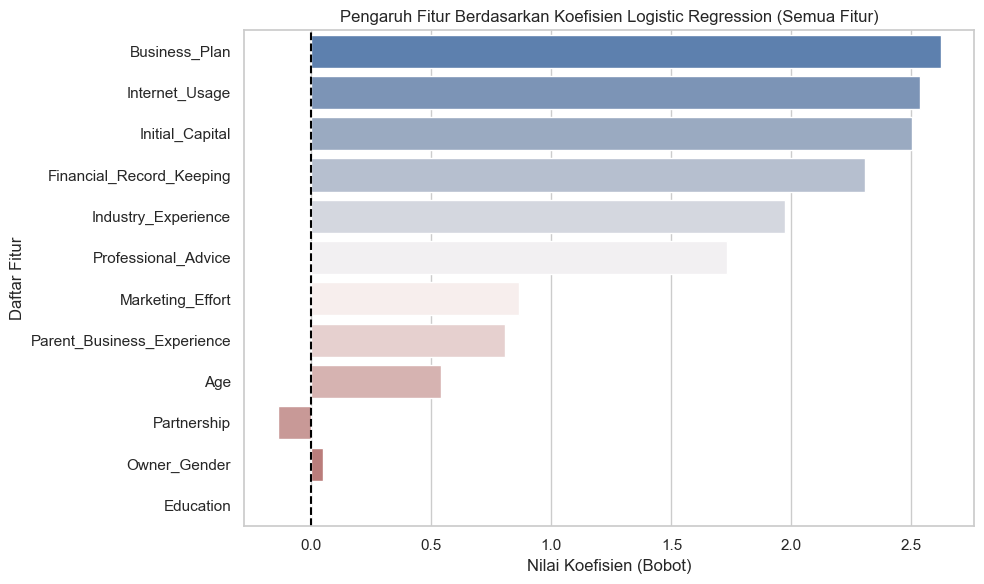

                     Fitur  Kepentingan_Koefisien
             Business_Plan               2.622367
            Internet_Usage               2.535786
           Initial_Capital               2.503162
  Financial_Record_Keeping               2.305329
       Industry_Experience               1.973963
       Professional_Advice               1.729872
          Marketing_Effort               0.866780
Parent_Business_Experience               0.807695
                       Age               0.540043
               Partnership              -0.141142
              Owner_Gender               0.046622
                 Education              -0.003079


In [30]:
# ==========================================
# EXTRAKSI KOEFISIEN UNTUK JUSTIFIKASI SELEKSI FITUR
# ==========================================

coefficients = model_lr.coef_[0]
feature_names = X_train.columns

df_importance = pd.DataFrame(
    {"Fitur": feature_names, "Kepentingan_Koefisien": coefficients}
)

df_importance["Absolut"] = df_importance["Kepentingan_Koefisien"].abs()
df_importance = df_importance.sort_values(by="Absolut", ascending=False).drop(
    columns=["Absolut"]
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Kepentingan_Koefisien",
    y="Fitur",
    data=df_importance,
    palette="vlag",  
)

plt.title("Pengaruh Fitur Berdasarkan Koefisien Logistic Regression (Semua Fitur)")
plt.xlabel("Nilai Koefisien (Bobot)")
plt.ylabel("Daftar Fitur")
plt.axvline(x=0, color="black", linestyle="--")
plt.tight_layout()
plt.show()

print(df_importance.to_string(index=False))

In [31]:
# ==========================================
# SKENARIO 2: RETRAINING MODEL DENGAN FITUR TERPILIH (9 FITUR TERATAS)
# ==========================================

selected_features = [
    "Business_Plan",
    "Internet_Usage",
    "Initial_Capital",
    "Financial_Record_Keeping",
    "Industry_Experience",
    "Professional_Advice",
    "Marketing_Effort",
    "Parent_Business_Experience",
    "Age",
    # "Partnership",
]

X_train_final = X_train[selected_features]
X_test_final = X_test[selected_features]

model_lr_final = LogisticRegression(
    class_weight="balanced", random_state=42, max_iter=1000
)
model_lr_final.fit(X_train_final, y_train)

y_proba_lr_final = model_lr_final.predict_proba(X_test_final)[:, 1]

best_thresh_final = 0.5
best_f1_final = 0
y_pred_final_opt = None

for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (y_proba_lr_final >= thresh).astype(int)
    current_f1 = f1_score(y_test, preds, pos_label=1)
    if current_f1 > best_f1_final:
        best_f1_final = current_f1
        best_thresh_final = thresh
        y_pred_final_opt = preds

print("=" * 50)
print(f"HASIL EVALUASI SKENARIO 2 (MODEL FINAL - 9 FITUR)")
print("=" * 50)
evaluasi_cepat(
    f"Logistic Regression Final (Thresh: {best_thresh_final:.2f})",
    y_test,
    y_pred_final_opt,
)

HASIL EVALUASI SKENARIO 2 (MODEL FINAL - 9 FITUR)
=== STRATEGI: Logistic Regression Final (Thresh: 0.66) ===
Accuracy           : 0.9600 (96.0%)
Precision (Macro)  : 0.9286 (92.9%)
Recall (Macro)     : 0.9737 (97.4%)
F1-Score (Macro)   : 0.9480 (94.8%)

--- REPORT LENGKAP ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        38
           1       0.86      1.00      0.92        12

    accuracy                           0.96        50
   macro avg       0.93      0.97      0.95        50
weighted avg       0.97      0.96      0.96        50




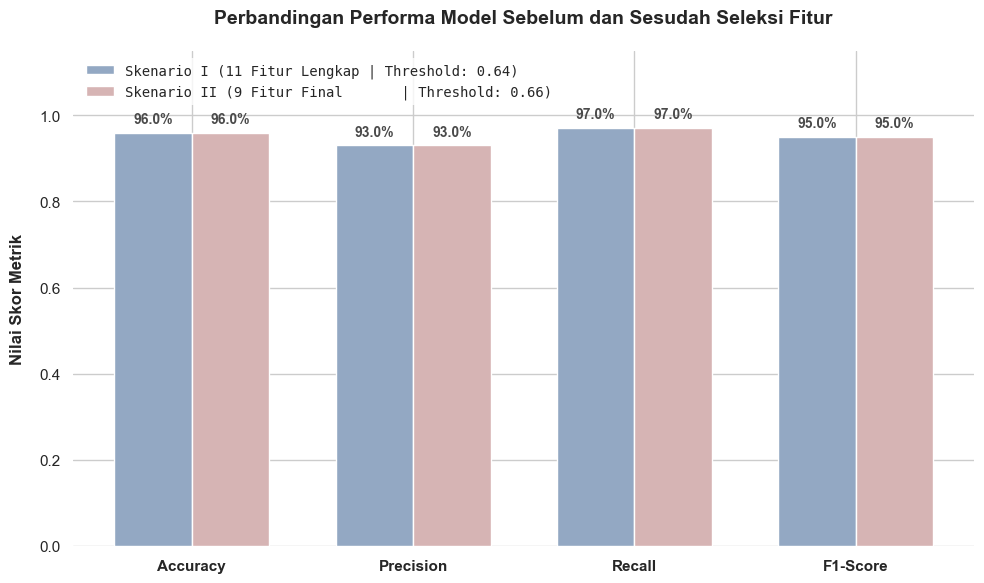

In [32]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
skenario_1 = [0.96, 0.93, 0.97, 0.95]  
skenario_2 = [0.96, 0.93, 0.97, 0.95]  

x = np.arange(len(metrics))  
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(
    x - width / 2,
    skenario_1,
    width,
    label="Skenario I (11 Fitur Lengkap | Threshold: 0.64)",
    color="#93a8c3",
)  
rects2 = ax.bar(
    x + width / 2,
    skenario_2,
    width,
    label="Skenario II (9 Fitur Final       | Threshold: 0.66)",
    color="#d6b4b4",
)  

ax.set_ylabel("Nilai Skor Metrik", fontsize=12, fontweight="bold", labelpad=10)
ax.set_title(
    "Perbandingan Performa Model Sebelum dan Sesudah Seleksi Fitur",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.15)  

ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    prop={"family": "monospace", "size": 10},
) 


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height*100:.1f}%",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 5),  
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="#4a4a4a",
        )


autolabel(rects1)
autolabel(rects2)

sns.despine(left=True, bottom=True)
plt.tight_layout()

# plt.savefig("perbandingan_performa_fitur.png", dpi=300, bbox_inches="tight")
plt.show()

## Skenario 3: Validasi Model

SKENARIO 3: VALIDASI FINAL & METRIK LENGKAP
Rata-rata F1-Macro (5-Fold CV): 0.9246 (+/- 0.0420)
--------------------------------------------------
Accuracy  : 0.9600 | Precision: 0.9286
Recall    : 0.9737 | F1-Score : 0.9480

--- REPORT LENGKAP ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        38
           1       0.86      1.00      0.92        12

    accuracy                           0.96        50
   macro avg       0.93      0.97      0.95        50
weighted avg       0.97      0.96      0.96        50



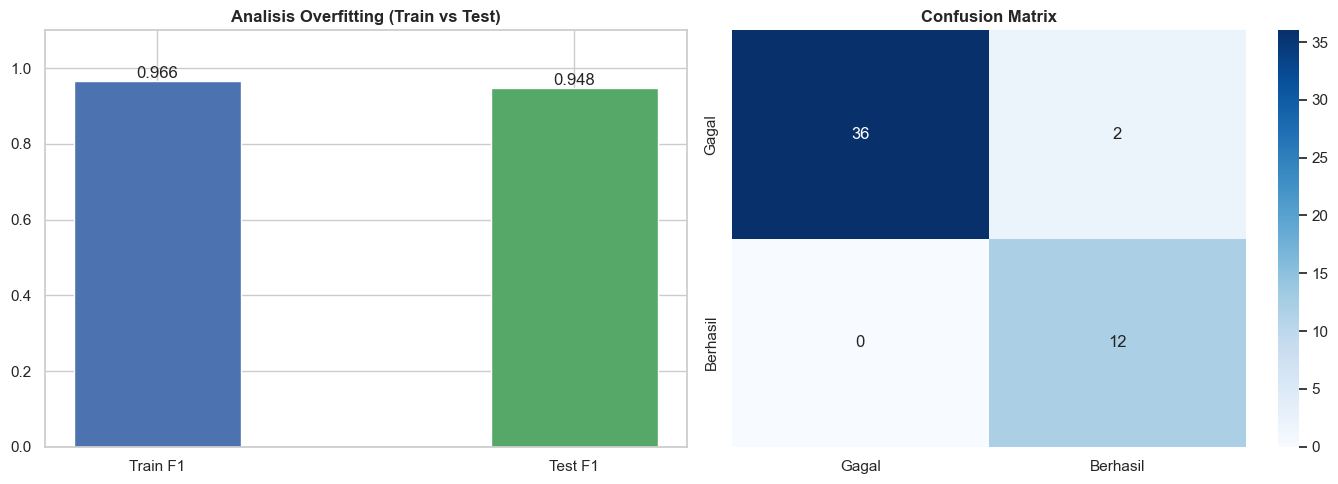

In [39]:
# ==========================================
# SKENARIO 3: VALIDASI ROBUSTNESS & METRIK FINAL
# ==========================================
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Validasi Stabilitas (K-Fold CV)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_lr_final, X_train_final, y_train, cv=skf, scoring='f1_macro')

print("=" * 50)
print("SKENARIO 3: VALIDASI FINAL & METRIK LENGKAP")
print("=" * 50)
print(f"Rata-rata F1-Macro (5-Fold CV): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("-" * 50)

# 2. Prediksi Final dengan Threshold Optimal
y_proba_final = model_lr_final.predict_proba(X_test_final)[:, 1]
y_pred_final = (y_proba_final >= best_thresh_final).astype(int)

# 3. Hitung Metrik Lengkap
acc = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final, average="macro")
rec = recall_score(y_test, y_pred_final, average="macro")
f1 = f1_score(y_test, y_pred_final, average="macro")

print(f"Accuracy  : {acc:.4f} | Precision: {prec:.4f}")
print(f"Recall    : {rec:.4f} | F1-Score : {f1:.4f}")
print("\n--- REPORT LENGKAP ---")
print(classification_report(y_test, y_pred_final))

# 4. Visualisasi (Perbandingan Train vs Test & Confusion Matrix)
y_pred_train = (model_lr_final.predict_proba(X_train_final)[:, 1] >= best_thresh_final).astype(int)
f1_train = f1_score(y_train, y_pred_train, average='macro')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Overfit Check
bars = ax[0].bar(['Train F1', 'Test F1'], [f1_train, f1], color=['#4C72B0', '#55A868'], width=0.4)
ax[0].set_ylim(0, 1.1)
ax[0].set_title("Analisis Overfitting (Train vs Test)", fontweight='bold')
for b in bars:
    ax[0].annotate(f'{b.get_height():.3f}', xy=(b.get_x() + b.get_width()/2, b.get_height()), ha='center', va='bottom')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1], xticklabels=['Gagal', 'Berhasil'], yticklabels=['Gagal', 'Berhasil'])
ax[1].set_title("Confusion Matrix", fontweight='bold')

plt.tight_layout()
plt.show()